# **~~~~ VISUALISATION WFLOW OUTPUT ~~~~**

##	*== PARAMETERS ==*

In [1]:
using CSV, Dates, Tables, NCDatasets, Dates
Path_Home = @__DIR__
cd(Path_Home)
include("Julia//Parameters.jl")

Qriver_Name=:Qriver_1

StartYear    = 2021
StartMonth    = 01
StartDay      = 01
StartDate = Date(StartYear, StartMonth, StartDay)

EndYear    = 2021
EndMonth    = 07
EndDay      = 01
EndDate = Date(EndYear, EndMonth, EndDay)

const M_2_Mm = 1000.0
const Mm_2_M = 0.001
const Seconds_2_Days = 60 * 60 * 24


86400

In [2]:
Path_Wflow_NetCDF_Output = joinpath(Path_Root_NetCDF_Output, "output_" * 🎏_CatchmentName * ".nc")

@assert isfile(joinpath(Path_Wflow_NetCDF_Output))
WflowOutput = NCDatasets.NCDataset(Path_Wflow_NetCDF_Output)


Dataset: D:\JOE\MAIN\MODELS\WFLOW\Wflow.jl\Wflow\Data\output\Timoleague\output_Timoleague.nc
Group: /

Dimensions
   time = 181
   x = 996
   y = 533
   layer = 4

Variables
  x   (996)
    Datatype:    Float64 (Float64)
    Dimensions:  x
    Attributes:
     long_name            = x coordinate of projection
     standard_name        = projection_x_coordinate
     axis                 = X
     units                = m

  y   (533)
    Datatype:    Float64 (Float64)
    Dimensions:  y
    Attributes:
     long_name            = y coordinate of projection
     standard_name        = projection_y_coordinate
     axis                 = Y
     units                = m

  layer   (4)
    Datatype:    Float64 (Float64)
    Dimensions:  layer
    Attributes:
     long_name            = layer_index
     standard_name        = layer_index
     axis                 = Z

  time   (181)
    Datatype:    DateTime (Float64)
    Dimensions:  time
    Attributes:
     units                = days since

# *== Averaging output.netcdf_grid ==*

In [3]:
Path_Wflow_NetCDF_Output = joinpath(Path_Root_NetCDF_Output, "output_" * 🎏_CatchmentName * ".nc")

@assert isfile(joinpath(Path_Wflow_NetCDF_Output))
println(Path_Wflow_NetCDF_Output)

WflowOutput = NCDatasets.NCDataset(Path_Wflow_NetCDF_Output)

Precipitation        = Array(WflowOutput["Precipitation"])
PotentialEvaporation = Array(WflowOutput["PotentialEvaporation"])
Interception         = Array(WflowOutput["Interception"])
Evapotranspiration   = Array(WflowOutput["Evapotranspiration"])
SoilWaterUnsatDepth  = Array(WflowOutput["SoilWaterUnsatDepth"])

OverlandFlow         = Array(WflowOutput["OverlandFlow"])
OverlandVolume       = Array(WflowOutput["OverlandVolume"])
OverlandFlowToRiver	= Array(WflowOutput["OverlandFlowToRiver"])

SubsurfaceFlow       = Array(WflowOutput["SubsurfaceFlow"])
SubsurfaceFlowToRiver       = Array(WflowOutput["SubsurfaceFlowToRiver"])
# GroundwaterFlow       = Array(WflowOutput["GroundwaterFlow"])

close(WflowOutput)

Nx, Ny, Nt                      = size(Precipitation)

∑Precipitation_M3               = fill(0.0, Nt)
Precipitation_Mm                = fill(0.0, Nt)

∑PotentialEvapotranspiration_M3 = fill(0.0, Nt)
PotentialEvaporation_Mm         = fill(0.0, Nt)

∑Interception_M3                = fill(0.0, Nt)
Interception_Mm                 = fill(0.0, Nt)

∑InfiltrationSoil_M3            = fill(0.0, Nt)
InfiltrationSoil_Mm             = fill(0.0, Nt)

∑Evapotranspiration_M3          = fill(0.0, Nt)
Evapotranspiration_Mm           = fill(0.0, Nt)

∑SoilWaterUnsatDepth_M3         = fill(0.0, Nt)
SoilWaterUnsatDepth_Mm          = fill(0.0, Nt)

∑OverlandVolume_M3              = fill(0.0, Nt)
OverlandVolume_Mm               = fill(0.0, Nt)

∑OverlandFlow_M3                = fill(0.0, Nt)
OverlandFlow_Mm                 = fill(0.0, Nt)

∑OverlandFlowToRiver_M3         = fill(0.0, Nt)
OverlandFlowToRiver_Mm          = fill(0.0, Nt)

∑SubsurfaceFlow_M3              = fill(0.0, Nt)
SubsurfaceFlow_Mm               = fill(0.0, Nt)

∑SubsurfaceFlowToRiver_M3       = fill(0.0, Nt)
SubsurfaceFlowToRiver_Mm        = fill(0.0, Nt)

GroundwaterFlow_Mm              = fill(0.0, Nt)

NotMissing                      = fill(false, Nx, Ny)

DatesWflow                      = fill(Date(StartYear, StartMonth, StartDay), Nt)

# Counting active cells
	CountCell = 0
	 for iX=1:Nx, iY=1:Ny
		if Precipitation[iX, iY, 2] !== missing
			CountCell += 1
			NotMissing[iX, iY] = true
		end
	end

	CatchmentArea = CountCell * Param_ΔX₁ * Param_ΔX₁  # m2
	printstyled("	Number of grids = $CountCell , CatchmentSize = $CatchmentArea  m² \n", color = :green)

DatesWflow[1] = StartDate
for iT=1:Nt
	 for iX=1:Nx
		for iY=1:Ny
			if NotMissing[iX, iY]

            ∑Precipitation_M3[iT] 						+= Precipitation[iX, iY, iT] * Mm_2_M * Param_ΔX₁ * Param_ΔX₁
            ∑PotentialEvapotranspiration_M3[iT]  	+= PotentialEvaporation[iX, iY, iT] * Mm_2_M * Param_ΔX₁ * Param_ΔX₁
            ∑Interception_M3[iT] 						+= Interception[iX, iY, iT] * Mm_2_M * Param_ΔX₁ * Param_ΔX₁
				∑Evapotranspiration_M3[iT] 				+= Evapotranspiration[iX, iY, iT] * Mm_2_M * Param_ΔX₁ * Param_ΔX₁

				∑SoilWaterUnsatDepth_M3[iT]   			+= SoilWaterUnsatDepth[iX, iY, iT] * Mm_2_M * Param_ΔX₁ * Param_ΔX₁

            ∑OverlandVolume_M3[iT]          			+= OverlandVolume[iX, iY, iT]
				∑OverlandFlow_M3[iT]          		   += OverlandFlow[iX, iY, iT] * 24.0 * 60.0 # m3/s to m3/day

				if OverlandFlowToRiver[iX, iY, iT] !== missing
					∑OverlandFlowToRiver_M3[iT]         += OverlandFlowToRiver[iX, iY, iT] * Seconds_2_Days # m3/s to m3/day
				end

				if SubsurfaceFlowToRiver[iX, iY, iT] !== missing
					∑SubsurfaceFlowToRiver_M3[iT]         += SubsurfaceFlowToRiver[iX, iY, iT] * Seconds_2_Days # m3/s to m3/day
				end

				∑SubsurfaceFlow_M3[iT]    					+= SubsurfaceFlow[iX, iY, iT] * Param_ΔX₁ * Param_ΔX₁

				∑InfiltrationSoil_M3[iT] = ∑Precipitation_M3[iT] - ∑Interception_M3[iT]
				# ∑GroundwaterFlow_M3[iT]       += GroundwaterFlow[iX, iY, iT]
			end
		end
	end # for iX=1:Nx, iY=1:Ny

   Precipitation_Mm[iT]        = ∑Precipitation_M3[iT] * M_2_Mm / CatchmentArea
   PotentialEvaporation_Mm[iT] = ∑PotentialEvapotranspiration_M3[iT] * M_2_Mm / CatchmentArea
   Interception_Mm[iT]         = ∑Interception_M3[iT]  * M_2_Mm / CatchmentArea
   InfiltrationSoil_Mm[iT]     = ∑InfiltrationSoil_M3[iT] * M_2_Mm 	/ CatchmentArea
   Evapotranspiration_Mm[iT]   = ∑Evapotranspiration_M3[iT] * M_2_Mm / CatchmentArea

   SoilWaterUnsatDepth_Mm[iT]  = ∑SoilWaterUnsatDepth_M3[iT] * M_2_Mm / CatchmentArea
   OverlandVolume_Mm[iT]       = ∑OverlandVolume_M3[iT] * M_2_Mm / CatchmentArea
	OverlandFlow_Mm[iT]   		 = ∑OverlandFlow_M3[iT] * M_2_Mm / CatchmentArea
	SubsurfaceFlow_Mm[iT]       = ∑SubsurfaceFlow_M3[iT] * M_2_Mm / CatchmentArea

	OverlandFlowToRiver_Mm[iT]  = ∑OverlandFlowToRiver_M3[iT] * M_2_Mm / CatchmentArea

   InfiltrationSoil_Mm[iT]     = Precipitation_Mm[iT] - Interception_Mm[iT]

	DatesWflow[iT] +=  Dates.Day(iT)
end # for iT=1:Nt

InterceptionLost = 100.0 * sum(∑Interception_M3) / sum(∑Precipitation_M3)
printstyled("	Interception lost = $(floor(InterceptionLost)) %  \n", color = :green)


D:\JOE\MAIN\MODELS\WFLOW\Wflow.jl\Wflow\Data\output\Timoleague\output_Timoleague.nc
	Number of grids = 324770 , CatchmentSize = 8119250  m² 
	Interception lost = 11.0 %  


# **Reading Qriver** 
## *Reading from observations*

In [6]:
Path_TimeSeries = joinpath(Path_Root, Path_Forcing, Filename_Input_Forcing)
println(Path_TimeSeries)
@assert isfile(Path_TimeSeries)

# Reading climate data
	Data₀  = CSV.File(Path_TimeSeries; header=true)
	Year   = convert(Vector{Int64}, Tables.getcolumn(Data₀, :Year))
	Month  = convert(Vector{Int64}, Tables.getcolumn(Data₀, :Month))
	Day    = convert(Vector{Int64}, Tables.getcolumn(Data₀, :Day))
	Hour   = convert(Vector{Int64}, Tables.getcolumn(Data₀, :Hour))

	QriverObs_Day_M3  = convert(Vector, Tables.getcolumn(Data₀, :RiverDischarge_cumec))

	Time_Forcing = Date.(Year, Month, Day) #  <"standard"> "proleptic_gregorian" calendar

# Selecting time which is between Start_DateTime and End_DateTime
	True = fill(false::Bool, length(Year))
	for iT=1:length(Year)
		if (DatesWflow[1] ≤ Time_Forcing[iT] ≤ DatesWflow[end])
			True[iT] = true
		end
		if Time_Forcing[iT] > EndDate
			break
		end
	end # for iT=1:Nit

	QriverObs_Day_M3 = QriverObs_Day_M3[True[:]];# m3/day
	QriverObs_Day_Mm = (QriverObs_Day_M3 ./ CatchmentArea) .* 1000.0; # cumec to mm/ m2 / day


D:/JOE/MAIN/MODELS/WFLOW/DATA/CATCHMENTS/Timoleague\InputTimeSeries\TimeSeries_Process\Daily\Forcing_Daily_Timoleague.csv


## *Reading Qriver from Wflow*


In [ ]:
Path_Qwflow  = raw"D:\JOE\MAIN\MODELS\WFLOW\Wflow.jl\Wflow\Data\output\Timoleague\output_Timoleague.csv"
DataWflow    = CSV.File(Path_Qwflow; header=true)
Time_Wflow   = convert(Vector, Tables.getcolumn(DataWflow, :time))
Qriver_Wflow = convert(Vector{Float64}, Tables.getcolumn(DataWflow, Qriver_Name))
QriverWflow_Day_M3 = Qriver_Wflow .* 86400.0; # cumec to m3/day
QriverWflow_Day_Mm = (QriverWflow_Day_M3 ./ CatchmentArea) .* 1000.0; # cumec to mm/ m2 / day


## **CSV OUTPUTS**

In [10]:
# Water balance
# [Precipitation_Mm] - Interception_Average[iT] = Stemflow_Average[iT] + Throughfall_Average[iT]

Path_AverageFluxes_Csv₀ = joinpath(Path_Root, Path_WflowModelOutput)
mkpath(Path_AverageFluxes_Csv₀)

Path_AverageFluxes_Csv = joinpath(Path_AverageFluxes_Csv₀, Filename_WflowCatchementAverage_Csv)

Header = ["Date", "∑Precipitation[M3]", "∑PotentialEvapotranspiration[M3]", "∑Interception[M3]", "∑InfiltrationSoil[M3]", "∑Evapotranspiration[M3]", "∑SoilWaterUnsatDepth[M3]", "∑OverlandVolume[M3]", "∑OverlandFlow[M3]", "∑OverlandFlowToRiver[M3]", "∑SubsurfaceFlow[M3]", "QriverWflow_Day[M3]", "QriverObs_Day[M3]", "Precipitation[Mm]", "PotentialEvaporation[Mm]", "InfiltrationSoil[Mm]", "Evapotranspiration[Mm]", "SoilWaterUnsatDepth[Mm]", "OverlandVolume[Mm]", "OverlandFlow[Mm]", "OverlandFlowToRiver[Mm]", "SubsurfaceFlow[Mm]", "QriverWflow[Mm]", "QriverObs[mm]"]

CSV.write(Path_AverageFluxes_Csv, Tables.table([DatesWflow ∑Precipitation_M3 ∑PotentialEvapotranspiration_M3 ∑Interception_M3 ∑InfiltrationSoil_M3 ∑Evapotranspiration_M3 ∑SoilWaterUnsatDepth_M3 ∑OverlandVolume_M3 ∑OverlandFlow_M3 ∑OverlandFlowToRiver_M3 ∑SubsurfaceFlow_M3 QriverWflow_Day_M3  QriverObs_Day_M3 Precipitation_Mm PotentialEvaporation_Mm InfiltrationSoil_Mm Evapotranspiration_Mm SoilWaterUnsatDepth_Mm OverlandVolume_Mm OverlandFlow_Mm OverlandFlowToRiver_Mm SubsurfaceFlow_Mm QriverWflow_Day_Mm QriverObs_Day_Mm]), writeheader=true, header=Header, bom=true)


"D:/JOE/MAIN/MODELS/WFLOW/DATA/CATCHMENTS/Timoleague\\WflowModelOutput\\CatchementAverage_Timoleague.csv"

## **PLOTTING**

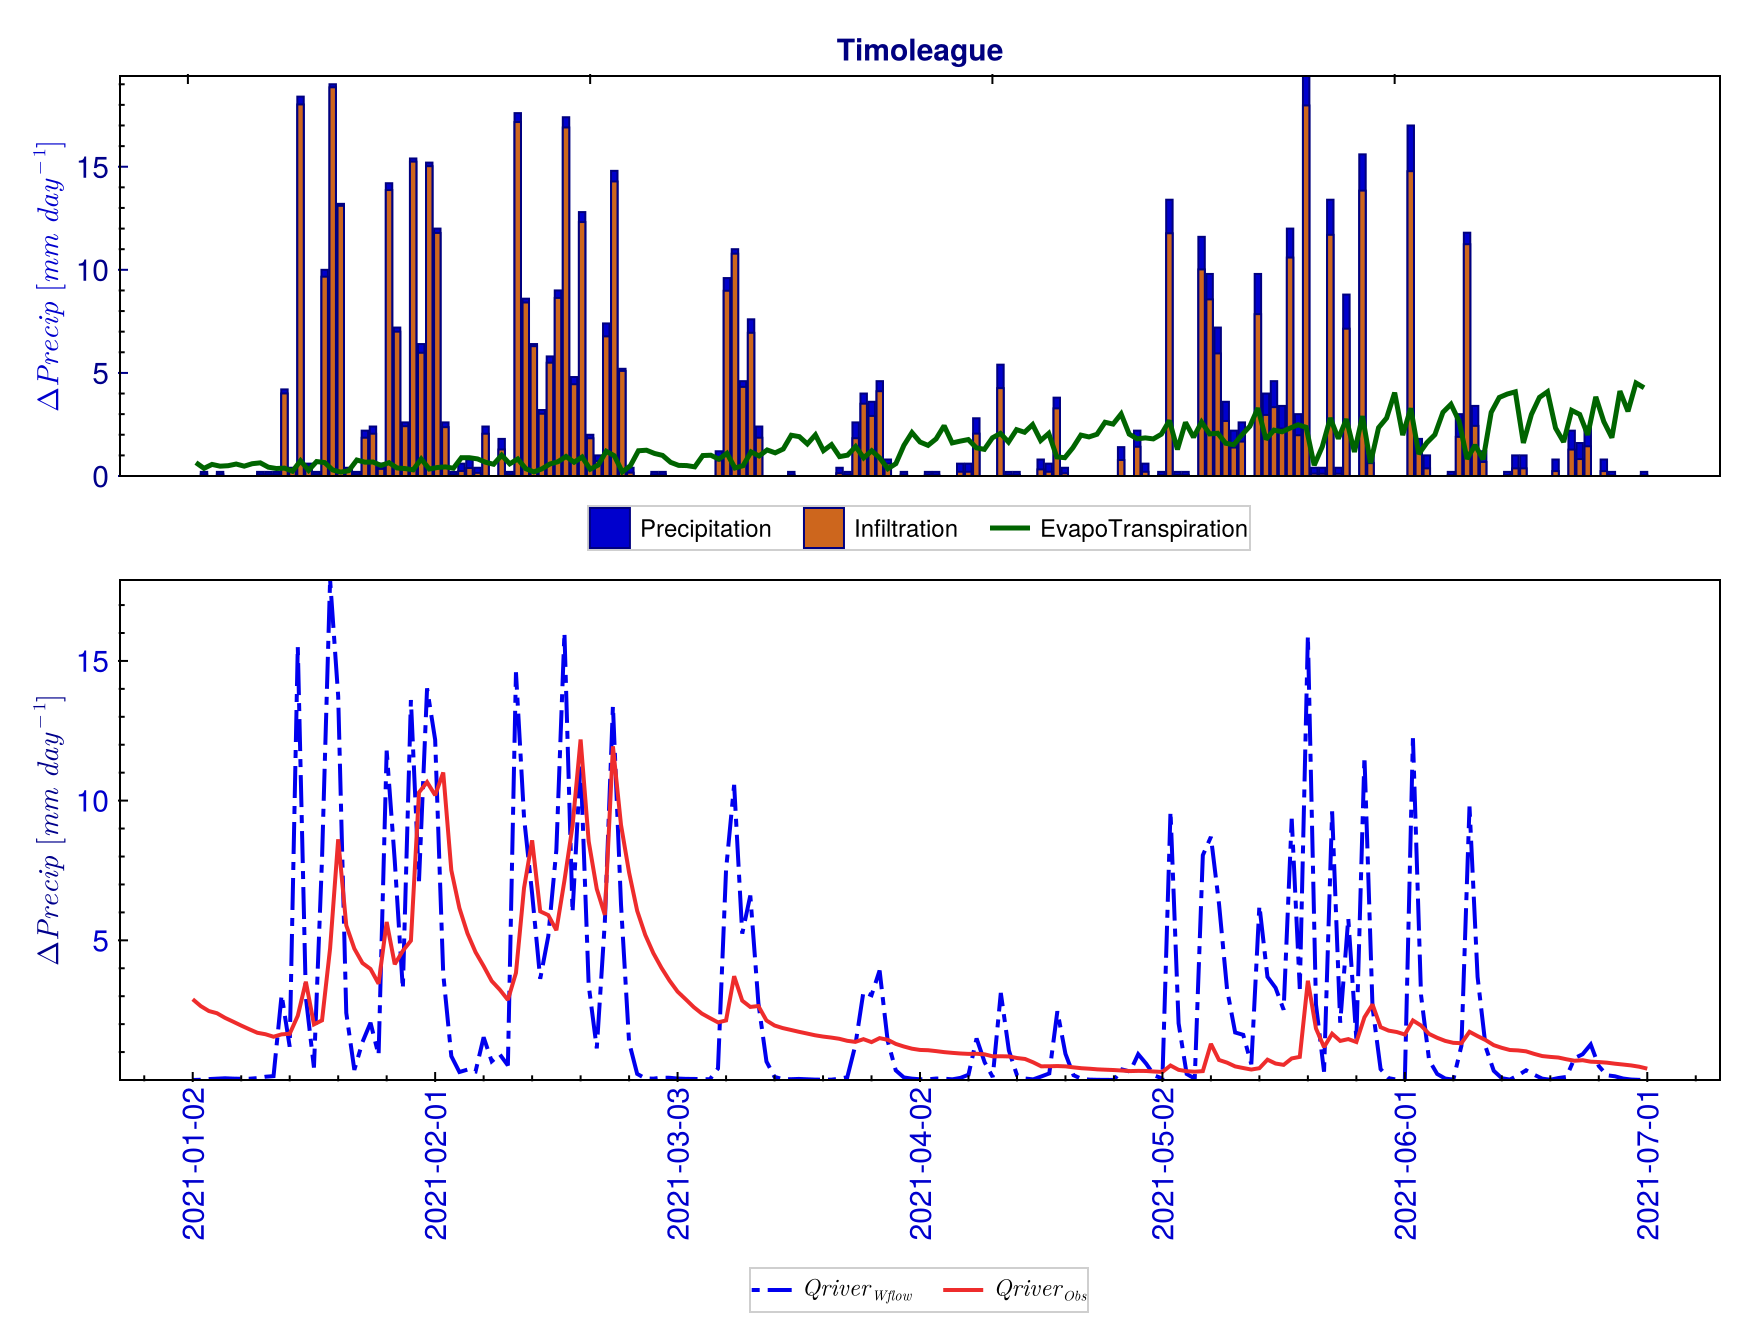

In [111]:
include("julia//GeoPlot.jl")

geoPlot.WFLOW_TIME(;DatesWflow, InfiltrationSoil_Mm, PotentialEvaporation_Mm, Precipitation_Mm, QriverObs_Day_Mm, QriverWflow_Day_Mm, 🎏_CatchmentName = "Timoleague", 🎏_GLMakie=false, Forcing_ΔT="Daily")
